# k-means и k-means++
Алгоритм k-means минимизирует сумму квадратов расстояний до центров кластеров: $\min_{\mu_1,\ldots,\mu_k} \sum_{i=1}^{n} \min_{j} ||x_i-\mu_j||^2$. Он чередует шаги присвоения ближайшего центра и пересчета центров как среднего. Инициализация k-means++ выбирает первый центр случайно, а следующие с вероятностью, пропорциональной квадрату расстояния до ближайшего центра, что уменьшает шанс плохой локальной минимизации.


## Используемые библиотеки
Используем `seaborn`, `matplotlib`. Из `sklearn` — реальный датасет `load_wine`, `StandardScaler`, `PCA`, `KMeans`, `silhouette_score`, `adjusted_rand_score`.


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score


In [2]:
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120
PRIMARY_COLOR = "#1f77b4"
SECONDARY_COLOR = "#ff7f0e"
HEATMAP_CMAP = "coolwarm"


## Датасет: описание и частичная распечатка
Используем реальный датасет **Wine** из `sklearn`: 178 образцов вина трёх сортов, описанных 13 химическими признаками. Это более правдоподобная задача кластеризации, чем синтетические облака: классы частично пересекаются, признаки имеют разные масштабы, а структура данных многомерная.


In [3]:
wine = load_wine(as_frame=True)
data = wine.frame
print(f"Размерность: {data.shape}")
data.head()


Размерность: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Предварительная обработка
Отделяем признаки от целевой переменной. Метки сортов не используем при обучении — они нужны только для внешней интерпретации качества кластеризации. Затем стандартизируем признаки и строим двумерную PCA-проекцию для визуализации.


In [4]:
features = data.drop(columns=["target"])
target = data["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

pca = PCA(n_components=2, random_state=42)
X_vis = pca.fit_transform(X_scaled)


## Тепловая карта корреляций
Покажем подмножество из первых 8 признаков. Для реальных химических измерений заметны корреляции между признаками, поэтому k-means работает уже не в идеальных условиях. Это делает пример ближе к реальной аналитике.


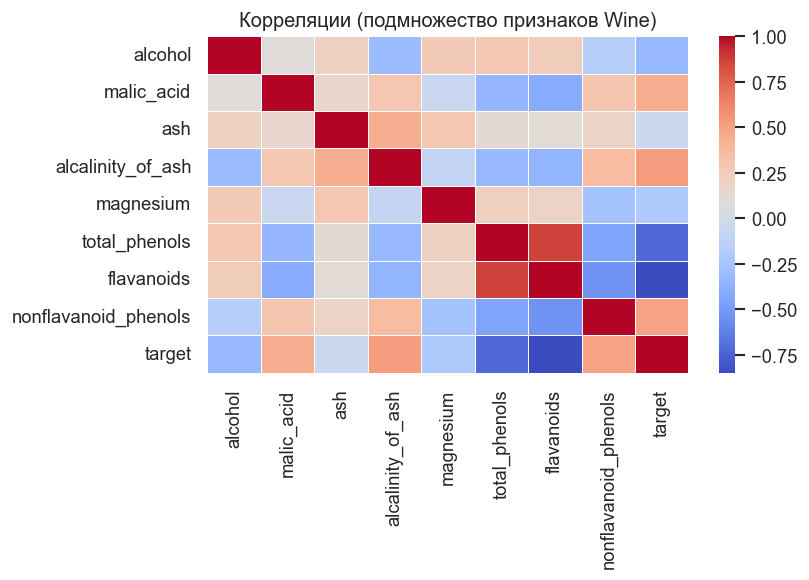

In [5]:
plt.figure(figsize=(7, 5))
subset_cols = list(features.columns[:8])
correlation = data[subset_cols + ["target"]].corr()
sns.heatmap(correlation, annot=False, cmap=HEATMAP_CMAP, linewidths=0.3)
plt.title("Корреляции (подмножество признаков Wine)")
plt.tight_layout()
plt.show()


## Обучение моделей
Обучаем два варианта k-means с `n_clusters=3`:
- **random** — центры инициализируются случайно;
- **k-means++** — центры выбираются более осторожно и обычно дают более стабильный результат.

В обоих случаях мы не используем истинные сорта при обучении.


In [6]:
kmeans_random = KMeans(n_clusters=3, init="random", n_init=10, random_state=42)
kmeans_pp = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)

kmeans_random.fit(X_scaled)
kmeans_pp.fit(X_scaled)


,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


## Прогнозы моделей
Сравниваем модели по двум метрикам:
- **Silhouette Score** — внутренняя метрика качества кластеризации без меток;
- **Adjusted Rand Index (ARI)** — внешняя метрика согласованности с известными сортами вина. Она используется только для анализа результата, а не для обучения.


In [7]:
labels_random = kmeans_random.labels_
labels_pp = kmeans_pp.labels_

score_random = silhouette_score(X_scaled, labels_random)
score_pp = silhouette_score(X_scaled, labels_pp)

ari_random = adjusted_rand_score(target, labels_random)
ari_pp = adjusted_rand_score(target, labels_pp)

print("KMeans on Wine")
print(f"Silhouette (random):    {score_random:.3f}")
print(f"Silhouette (k-means++): {score_pp:.3f}")
print(f"ARI (random):           {ari_random:.3f}")
print(f"ARI (k-means++):        {ari_pp:.3f}")


KMeans on Wine
Silhouette (random):    0.285
Silhouette (k-means++): 0.285
ARI (random):           0.897
ARI (k-means++):        0.897


## Графики выходных результатов
**Scatter-графики на PCA-проекции (2 панели).** Цвет точки — найденный кластер, крестики — центры. На реальных данных кластеры не обязаны идеально совпадать с сортами вина, но k-means++ обычно даёт более устойчивое разбиение и более разумное положение центров.


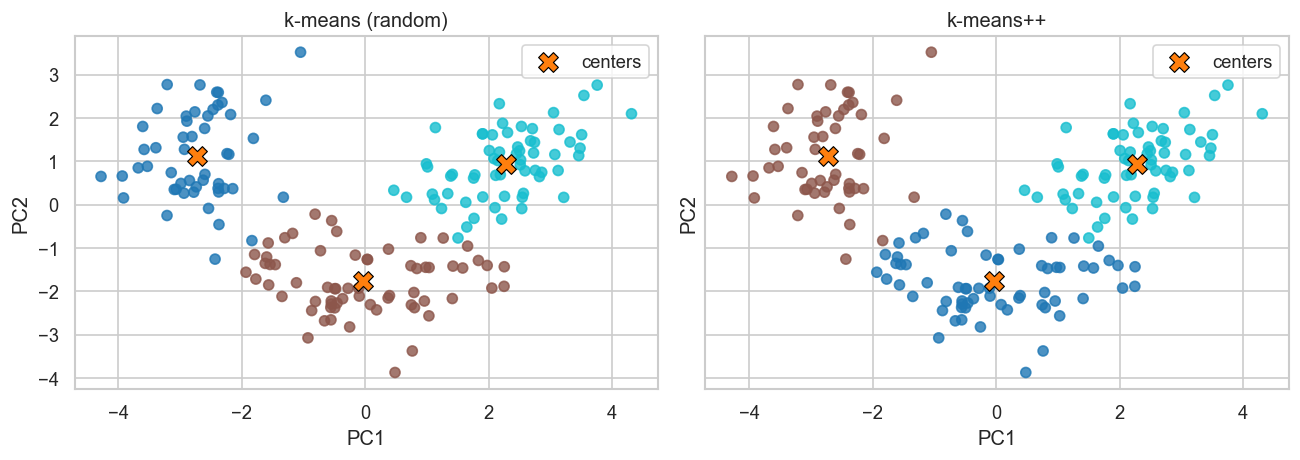

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

centers_random_vis = pca.transform(kmeans_random.cluster_centers_)
centers_pp_vis = pca.transform(kmeans_pp.cluster_centers_)

for ax, labels, centers, title in [
    (axes[0], labels_random, centers_random_vis, "k-means (random)"),
    (axes[1], labels_pp, centers_pp_vis, "k-means++"),
]:
    ax.scatter(
        X_vis[:, 0],
        X_vis[:, 1],
        c=labels,
        cmap="tab10",
        alpha=0.8,
    )
    ax.scatter(
        centers[:, 0],
        centers[:, 1],
        s=140,
        color=SECONDARY_COLOR,
        marker="X",
        edgecolor="black",
        linewidth=0.7,
        label="centers",
    )
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()

plt.tight_layout()
plt.show()
